## Question 1

---

In [142]:
##Q1:PART1 : Creation of Random Sample##

#imports
import numpy as np
import pandas as pd

#defining the days of the week for 28 days
oneweek = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
dweek = oneweek * 4 #weeks created for all 28 days


#random number generation
Tt = np.random.normal(loc=20, scale=10, size=28)
#index is defined
indx = np.arange(1,29)
#Creating a dataframe for ease of use
mydata = pd.DataFrame({"DayNum":indx,"Day":dweek,"Temperature":Tt})

---

In [143]:
##Q1:PART2 : For Loop Process##

#Defining an empty numeric for Ut
Ut = [0] * 28
for i in range(0,len(mydata)): # for each i from 1 to 29 (29 because it should cover the last day)
    #assigning today
    today = dweek[i] #today starts with monday, and iterates 1 day at a time as i increases
    #Calculating Ft according to the day
    if today in ["Saturday", "Sunday"]:
        Ft = 0.8
    else:
        Ft = 1.2
    Ut[i] = (50 + (-0.1*Tt[i]) + (5 * (1.5 + 2 + 0.5 ))) * Ft #Ut is calculated according to the given formula

#Printing
mydata = pd.DataFrame({"DayNum":indx,"Day":dweek,"Temperature":Tt,"Ut":Ut})
print(mydata)


    DayNum        Day  Temperature         Ut
0        1     Monday    21.158673  81.460959
1        2    Tuesday    11.270944  82.647487
2        3  Wednesday     4.395469  83.472544
3        4   Thursday    16.747198  81.990336
4        5     Friday     8.520856  82.977497
5        6   Saturday    17.968607  54.562511
6        7     Sunday    15.760583  54.739153
7        8     Monday    16.545672  82.014519
8        9    Tuesday    45.095837  78.588500
9       10  Wednesday    13.777012  82.346759
10      11   Thursday    16.436323  82.027641
11      12     Friday    16.589463  82.009264
12      13   Saturday    21.960651  54.243148
13      14     Sunday    19.013959  54.478883
14      15     Monday    30.630537  80.324336
15      16    Tuesday    10.251148  82.769862
16      17  Wednesday    20.387734  81.553472
17      18   Thursday    27.253610  80.729567
18      19     Friday    42.637453  78.883506
19      20   Saturday    12.706261  54.983499
20      21     Sunday    26.097363

---

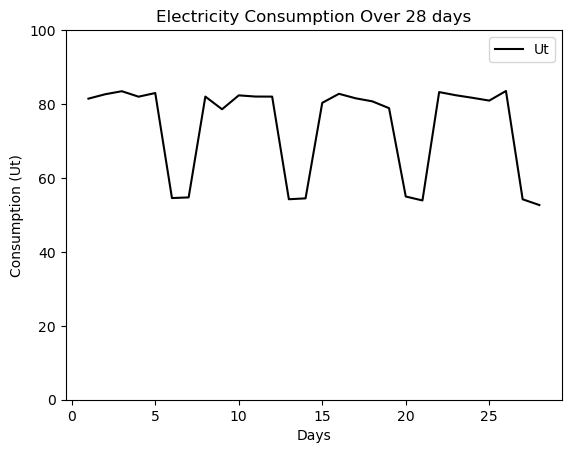

In [161]:
##Q1:PART3 : Creating a Line Chart Plot## 

import matplotlib.pyplot as plt
plt.plot(mydata.DayNum, mydata.Ut, label='Ut', color='black')
plt.title("Electricity Consumption Over 28 days")
plt.xlabel("Days")
plt.ylim(0, 100)
plt.ylabel("Consumption (Ut)")
plt.legend()
plt.show()

---

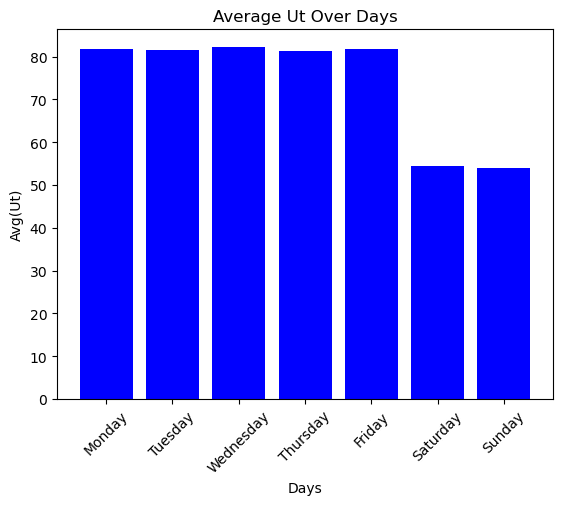

In [167]:
##Q1:Part 4 : Calculating Mean values for each day of the week ##

average_values = mydata.groupby('Day')['Ut'].mean() #I already had mydata for ease of use.
average_values.index = pd.CategoricalIndex(average_values.index, categories=oneweek, ordered=True) #I had to sort it for better visualization.

#The Plot
plt.bar(average_values.sort_index().index, average_values.sort_index().values, color='blue')
# Adding labels and title for better visualization
plt.xlabel('Days')
plt.ylabel('Avg(Ut)')
plt.title('Average Ut Over Days')
plt.xticks(rotation=45)  # Rotate the x-axis labels
plt.show()

---

There is a noticable difference in the Line Chart as the line visibly flactuates specificially around 6-7, 13-14,20-21, 27-28 values.
#A better way to see it was to group by means, and visually present it as given in the bar chart above.
Weekend's average is significantly lower than weekdays.


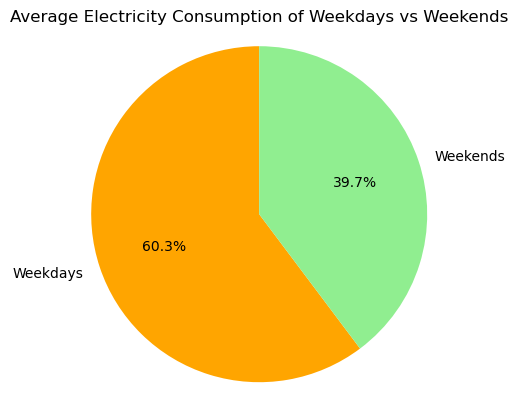

By looking at this graph, and found weekday_avg,weekend_avg values, we can claim that;
WEEKDAY consumption is approximately 51.9% higher than WEEKEND consumption.


In [202]:
##Q1:Part 5:Comparing Weekdays vs Weekends ##

print("There is a noticable difference in the Line Chart as the line visibly flactuates specificially around 6-7, 13-14,20-21, 27-28 values.")
print("#A better way to see it was to group by means, and visually present it as given in the bar chart above.")
print("Weekend's average is significantly lower than weekdays.")

#To compare weekdays & weekends, we can group them by average accordingly, and present result in a pie chart as,

#defining what is weekday and what is weekend,
weekdays = oneweek[0:5]
weekends = oneweek[6:7]

#calculating averages for each class
weekday_avg = average_values[average_values.index.isin(weekdays)].mean()
weekend_avg = average_values[average_values.index.isin(weekends)].mean()

# Preparing data for the pie chart
pie_data = [weekday_avg, weekend_avg]
labels = ['Weekdays', 'Weekends']

# Plot the pie chart
plt.pie(pie_data, labels=labels, 
        autopct='%1.1f%%',  #internal data labels
        colors=['orange', 'lightgreen'], startangle=90) #fill colors
plt.title('Average Electricity Consumption of Weekdays vs Weekends')
plt.axis('equal')  # Ensures the pie chart is circular
plt.show()

print("By looking at this graph, and found weekday_avg,weekend_avg values, we can claim that;")
print("WEEKDAY consumption is approximately 51.9% higher than WEEKEND consumption.")

---

## Question 2

---

In [301]:
## Q2 : Part 1: Finding The Roots ##

#imports
import numpy as np
import matplotlib.pyplot as plt

# Initialization
stopwhen = 1/pow(10,6)

def newtrial(xk): ##for the 4th question, I define it all in a function to be able to call it later.
#Defining all the Functions: fx, 1st derivative of fx and 2nd Derivative as,
    
    def fx(x):
        return 2*x**2 + 3*np.sin(x) - 4*np.exp(0.5*x) + np.log(x)
    
    def fp(x):
        return 4*x + 3*np.cos(x) - 2*np.exp(0.5*x) + 1/x
    
    def fpp(x):
        return 4 - 3*np.sin(x) - np.exp(0.5*x) -1/(x**2)
    
    
    
    # Creating Lists & Empty Lists to store data
    x_values = [xk]
    errors = []
    
    # Iteration to find the root
    while True:
        x_next = xk - (fx(xk) / (10 * fp(xk))) - (fp(xk) / (600 * fpp(xk)))
        error = abs(x_next - xk)
        x_values.append(x_next)
        errors.append(error)
        
        # Stopping condition
        if error < stopwhen:
            break
        
        xk = x_next
    # Reporting the results
    return(xk,fx(xk))
print(f"Root found:", newtrial(2)[0])

Root found: 1.753776904812686


---

In [196]:
## Q2 : Part 2 : Number of iterations ##

# Reporting the results
print(f"Number of iterations: {len(errors)}")

Number of iterations: 93


---

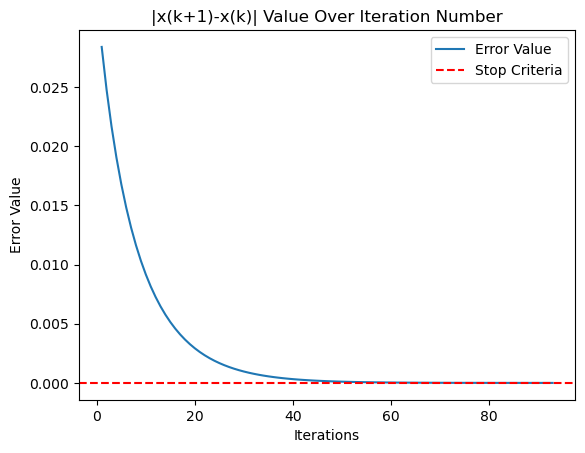

In [197]:
## Q2 : Part 3 : Plotting ##

# Plotting the error vs iterations
plt.plot(range(1, len(errors) + 1), errors, label='Error Value')
plt.xlabel("Iterations")
plt.ylabel("Error Value")
plt.title("|x(k+1)-x(k)| Value Over Iteration Number")
plt.axhline(y=1e-6, color='r', linestyle='--', label='Stop Criteria')
plt.legend()
plt.show()

---

In [223]:
# Q2 : Part 4 : Different Starting Points ##

print("To analyze the performance of the result, let's see if our root(x) is able to make f(x) equal to 0 or not.")
current_root = newtrial(2)[0]
current_Result = newtrial(2)[1]
print(f"Current Input: ",current_root)
print(f"Current f(x) Result: ",current_Result)

print("Our f(x) result is 0.05; not 0. Mainly because our iterations have an error limitation. Since we can't change the error limitation, ")
print("we may start from a better point to reach to goal.")
print("to be able to call our experiment, I have defined everything in a function named newtrial. Let's try new values") 

#Creating a new trial loop
#First, defining empty lists
fxresults = []
myi = []
for i in np.arange(1, 3, 0.01):
    fxresults.append(newtrial(i)[1])
    myi.append(i)
print(f"For the following starting point(root value as input): ", myi[fxresults.index(min(fxresults))])
print(f"The lowest f(x) value is: ",min(fxresults))
print("This proves that by using different starting point as given above, I can reach to a better f(x) result closer to 0,")
print("which means that the root is more likely to help f(x) reach to 0. In other words, better performance.")
print("About 'Identify at least one starting point where the method fails to converge', Since x in any log() shall be in (0,+infinite) ")
print("f(x) function returns an error when it is negative or zero. Also values such as xk=2000 returns 'overflow in exp' error.")

To analyze the performance of the result, let's see if our root(x) is able to make f(x) equal to 0 or not.
Current Input:  1.753776904812686
Current f(x) Result:  0.049516748848764114
Our f(x) result is 0.05; not 0. Mainly because our iterations have an error limitation. Since we can't change the error limitation, 
we may start from a better point to reach to goal.
to be able to call our experiment, I have defined everything in a function named newtrial. Let's try new values
For the following starting point(root value as input):  1.3700000000000003
The lowest f(x) value is:  0.049474399212696696
This proves that by using different starting point as given above, I can reach to a better f(x) result closer to 0,
which means that the root is more likely to help f(x) reach to 0. In other words, better performance.
About 'Identify at least one starting point where the method fails to converge', Since x in any log() shall be in (0,+infinite) 
f(x) function returns an error when it is negative

---

## Question 3

---

In [255]:
## Q3 : Part1 ##

#imports
import pandas as pd
import numpy as np

#data import
mypath = "C:\\Users\\Engin-Eer\\OneDrive - University of Southampton\\Semester 1\\MATH6005 - Introduction to Python\\Assignment 1\\"
data = pd.read_csv(mypath + 'weather_data.csv')

# Defining given variables for the calculation
a = 0.05
b = 0.04
c = 0.03
d = 0.02

# Defining Rain Probability Function
def Pr(row):
    return 1 / (1 + np.exp(-(a * row['tmax'] + b * row['tmin'] + c * row['af'] - d * row['sun'])))

# Apply the function to calculate Prain for each row in the entire dataset
data['Pr'] = data.apply(Pr, axis=1)

# Filter the data for the year 2020
data2020 = data[data['Year'] == 2020]

# Filtering for London, Manchester, Southampton in 2020
london_data = data2020[data2020['station'] == 'London']
manchester_data = data2020[data2020['station'] == 'Manchester']
southampton_data = data2020[data2020['station'] == 'Southampton']

# Mean for each station in 2020
avgLondon = london_data['Pr'].mean()
avgManchester = manchester_data['Pr'].mean()
avgSouthampton = southampton_data['Pr'].mean()

print(f"Avg probability for rainfall in London for 2020 is: {avgLondon}")
print(f"Avg probability for rainfall in Manchester for 2020 is: {avgManchester}")
print(f"Avg probability for rainfall in Southampton for 2020 is: {avgSouthampton}")


Avg probability for rainfall in London for 2020 is: 0.19582012478384594
Avg probability for rainfall in Manchester for 2020 is: 0.17075761189568164
Avg probability for rainfall in Southampton for 2020 is: 0.1654813115569872


---

In [270]:
## Q3 : Part2 ##

#Filtering 2023 data,
data_2023 = data.query('Year == 2023')

# Max Pr for 2023,
maxPr = data_2023['Pr'].max()

# VlookUp for relevant data
cityWithMostRain = data_2023.loc[data_2023['Pr'] == maxPr, 'station']

# If you want just the first station with the highest probability:
cityWithMostRainFirst = cityWithMostRain.iloc[0]

print(f"2023's city with most likely raining probability is: {cityWithMostRainFirst} with {np.round(maxPr,4)*100}% probability")

2023's city with most likely raining probability is: Manchester with 65.91% probability


---

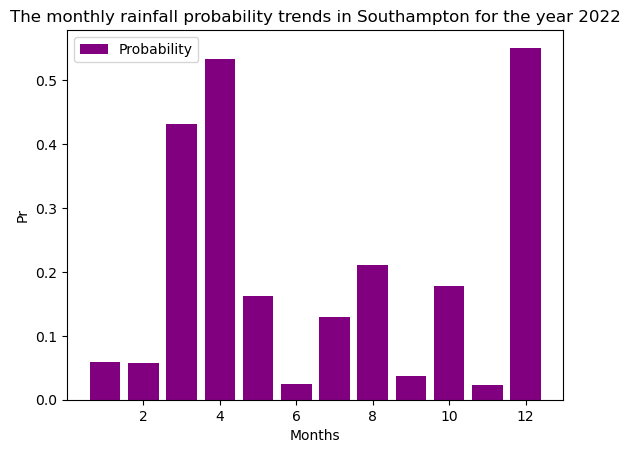

In [279]:
## Q3 : Part3 ##

#imports
import matplotlib.pyplot as plt

#defining new dataset as wb(workbench)
wb = data.query('station == "Southampton" and Year == 2022')

#the plot
plt.bar(wb.Month, wb.Pr, label='Probability', color='purple')
plt.title("The monthly rainfall probability trends in Southampton for the year 2022")
plt.xlabel("Months")
#plt.ylim(0, 100)
plt.ylabel("Pr")
plt.legend()
plt.show()


---

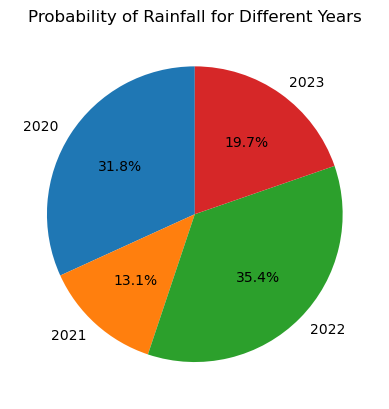

In [298]:
## Q3 : Part4 ##

#imports
import matplotlib.pyplot as plt

#defining new dataset as wb(workbench)
newwb = data.query('station == "Liverpool"')

#the mean after applying group by,
avgLiverpool = newwb.groupby('Year')['Pr'].mean() #I already had mydata for ease of use.
avgLiverpool

Lyears = avgLiverpool.index
Lvalues = avgLiverpool.values
#the plot

plt.pie(Lvalues, labels=Lyears, autopct='%1.1f%%', startangle=90)
plt.title('Probability of Rainfall for Different Years')
plt.show()